In [3]:
import pandas as pd
import seaborn as sns


In [4]:
df = pd.read_csv('exercise (1).csv')
df.head(10)

,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest
5,5,2,low fat,93,30 min,rest
6,6,3,low fat,97,1 min,rest
7,7,3,low fat,97,15 min,rest
8,8,3,low fat,94,30 min,rest
9,9,4,low fat,80,1 min,rest


In [5]:
#data cleaning
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  90 non-null     int64
 1   id          90 non-null     int64
 2   diet        90 non-null     str  
 3   pulse       90 non-null     int64
 4   time        90 non-null     str  
 5   kind        90 non-null     str  
dtypes: int64(3), str(3)
memory usage: 4.3 KB


In [18]:
#missing values
print(df.isnull().sum())

Unnamed: 0    0
id            0
diet          0
pulse         0
time          0
kind          0
dtype: int64


In [17]:
df.duplicated().sum()

np.int64(0)

In [9]:
import sklearn

print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.8.0


**dirty cafe sales**

In [ ]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
#load the dataset

df = pd.read_csv('c:/Users/aqib farooq/Downloads/python_daily_tasks/dirty_cafe_sales.csv')
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [ ]:
#initial data exploration

#check column name nd datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [15]:
#check dtype 
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

In [16]:
#get basic statistics
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [ ]:
#check col names
for i , col in enumerate(df.columns):
    print(f" {i+1}. {col}")

 1. Transaction ID
 2. Item
 3. Quantity
 4. Price Per Unit
 5. Total Spent
 6. Payment Method
 7. Location
 8. Transaction Date


In [18]:
#obvious issues
print("\n checking unique values in col:")


 checking unique values in col:


In [28]:
#get all columns
for col in df.select_dtypes(include=['object','string']):
    print(col)

Transaction ID
Item
Quantity
Price Per Unit
Total Spent
Payment Method
Location
Transaction Date


In [ ]:
#scnd method to get col
tect_col = df.select_dtypes(include=['object','string']).columns
print(tect_col)

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')


**find missing values**

In [4]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [7]:
df = pd.read_csv('c:/Users/aqib farooq/Downloads/python_daily_tasks/dirty_cafe_sales.csv')
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [ ]:
#isnull check each cell empty or fill
missing_count = df.isnull()
print(missing_count)

      Transaction ID   Item  Quantity  Price Per Unit  Total Spent  \
0              False  False     False           False        False   
1              False  False     False           False        False   
2              False  False     False           False        False   
3              False  False     False           False        False   
4              False  False     False           False        False   
...              ...    ...       ...             ...          ...   
9995           False  False     False           False        False   
9996           False   True     False            True        False   
9997           False  False     False           False        False   
9998           False  False     False            True        False   
9999           False  False     False           False        False   

      Payment Method  Location  Transaction Date  
0              False     False             False  
1              False     False             False  
2     

In [ ]:
#.sum() add all true values
missing_count = df.isnull().sum()
missing_count

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [14]:
#calculate percentage
missing_percent = (df.isnull().sum() / len(df) * 100)
missing_percent

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

In [ ]:
#create table of all this

missing_table = pd.DataFrame({
    'column_name': df.columns,
    'total rows': len(df), 
    'missing_count': missing_count.values,
    'missing_percent':missing_percent.values
})
print(missing_table)

        column_name  total rows  missing_count  missing_percent
0    Transaction ID       10000              0             0.00
1              Item       10000            333             3.33
2          Quantity       10000            138             1.38
3    Price Per Unit       10000            179             1.79
4       Total Spent       10000            173             1.73
5    Payment Method       10000           2579            25.79
6          Location       10000           3265            32.65
7  Transaction Date       10000            159             1.59


In [ ]:
#show only col that have missing values

columns_with_missing = missing_table[missing_table['missing_count'] > 0] 
print("\n COLUMNS WITH MISSING VALUES:") 
if len(columns_with_missing) > 0: 
    for index, row in columns_with_missing.iterrows(): 
        print(f"   • {row['column_name']}: {row['missing_count']} missing ({row['missing_percent']:.1f}%)") 
else: 
    print(" No missing values found!") 


 COLUMNS WITH MISSING VALUES:
   • Item: 333 missing (3.3%)
   • Quantity: 138 missing (1.4%)
   • Price Per Unit: 179 missing (1.8%)
   • Total Spent: 173 missing (1.7%)
   • Payment Method: 2579 missing (25.8%)
   • Location: 3265 missing (32.6%)
   • Transaction Date: 159 missing (1.6%)


**visualize missing values with heatmap**

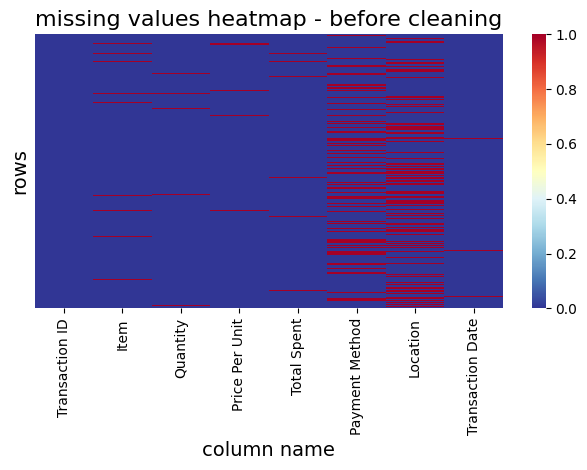

In [37]:
plt.Figure(figsize=(14,8))
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='RdYlBu_r')
plt.title('missing values heatmap - before cleaning', fontsize= 16)
plt.xlabel('column name', fontsize= 14)
plt.ylabel('rows', fontsize= 14)
plt.tight_layout()
plt.show()

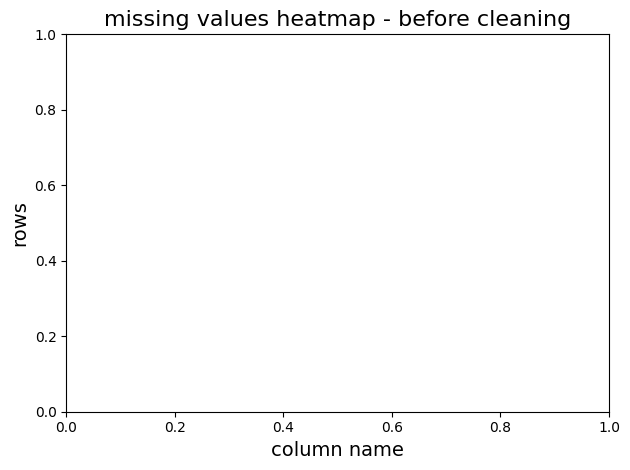

In [18]:
plt.title('missing values heatmap - before cleaning', fontsize= 16)
plt.xlabel('column name', fontsize= 14)
plt.ylabel('rows', fontsize= 14)
plt.tight_layout()
plt.show()

**drop colm with 50% missing values**

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('c:/Users/aqib farooq/Downloads/python_daily_tasks/dirty_cafe_sales.csv')
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [7]:

df_clean = df.copy() 
print("Created working copy of dataset")

# Find columns with more than 50% missing values 
columns_to_remove = [] 
threshold = 50  # 50% threshold 
for column in df_clean.columns:

# Calculate missing percentage for this column 
    missing_percent = (df_clean[column].isnull().sum() / len(df_clean)) * 100 

# Check if it's above our threshold 
if missing_percent > threshold: 
    columns_to_remove.append(column) 
    print(f" Column '{column}' has {missing_percent:.1f}% missing - MARKED FOR REMOVAL") 
# Remove those columns 
if len(columns_to_remove) > 0: 
    df_clean = df_clean.drop(columns=columns_to_remove) 
    print(f"\n Removed {len(columns_to_remove)} columns: {columns_to_remove}") 
else: 
    print("\n No columns need to be removed (all have <50% missing)") 
print(f"\n New dataset shape: {df_clean.shape}") 
print(f"   Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}") 
# Show remaining columns 
print("\n Remaining columns:") 
for i, col in enumerate(df_clean.columns): 
    print(f"   {i+1}. {col}") 

Created working copy of dataset

 No columns need to be removed (all have <50% missing)

 New dataset shape: (10000, 8)
   Rows: 10000, Columns: 8

 Remaining columns:
   1. Transaction ID
   2. Item
   3. Quantity
   4. Price Per Unit
   5. Total Spent
   6. Payment Method
   7. Location
   8. Transaction Date


In [21]:
#seperate numaric and text column

# Find numeric columns (integers and floats) 
number_columns = [] 
for column in df_clean.columns: 
# Check data type: int64 = integer, float64 = decimal 
    if df_clean[column].dtype in ['int64', 'float64']: 
        number_columns.append(column) 
# Find text columns (objects) 
text_columns = [] 
for column in df_clean.columns: 
    if df_clean[column].dtype == 'object': 
        text_columns.append(column) 
print(f"\n NUMERIC COLUMNS ({len(number_columns)} found):") 
for col in number_columns: 
    print(f"   • {col}") 
print(f"\n TEXT COLUMNS ({len(text_columns)} found):") 
for col in text_columns: 
     print(f"   • {col}") 

# Check for columns that might be numeric but stored as text 
print("\n CHECKING FOR NUMBERS STORED AS TEXT:") 
for col in text_columns: 
# Try to convert first few values to see if they're actually numbers 
    Quantity = df_clean[col].dropna().iloc[:5] if len(df_clean[col].dropna()) > 0 else [] 
could_be_numeric = False 
for val in Quantity:
    try: 
         float(val)
         could_be_numeric = True
    except: 
        pass 
    
if could_be_numeric: 
    print(f"   • {col}: Might contain numbers stored as text") 


 NUMERIC COLUMNS (0 found):

 TEXT COLUMNS (0 found):

 CHECKING FOR NUMBERS STORED AS TEXT:


NameError: name 'Quantity' is not defined